# Configurando bibliotecas, Dataset e fazendo conexão com W&B


In [ ]:
!pip install -r requirements.txt

In [ ]:
import wandb
import pandas as pd
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader , TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.stats import ks_2samp , chi2_contingency
import yaml , random, matplotlib.pyplot as plt
import kagglehub , shutil , os
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

## Baixando base de dados

In [ ]:
# Download do dataset
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")
print(f"Downloaded to: {path}")

# Copia o dataset para a pasta destinada
destination = os.getcwd ()
shutil.copytree(path , os.path.join(destination , "data/"), dirs_exist_ok=True)

# Carregar aquivo principal de acidentes
df_raw = pd.read_csv("data/star_classification.csv", low_memory=False)

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns) }...")

## Login no W&B

In [ ]:
import key

API_KEY = key.KEY 
wandb.login(key=API_KEY)

## Registrar dados brutos W&B

In [ ]:
wandb.init(project="star-classification", job_type="load_raw", name="load_raw")
artifact = wandb.Artifact("raw_data", type="dataset", description="star_classification raw dataset from Kaggle")
temp_path = "data/temp_raw.csv"
df_raw.to_csv(temp_path , index=False)
artifact.add_file(temp_path)
wandb.log_artifact(artifact)
wandb.summary["rows"] = len(df_raw)
wandb.summary["columns"] = list(df_raw.columns)
wandb.finish()
print("Artefato raw_data salvo no W&B")

# Pré-processamento e Limpeza dos Dados

## Criando arquivo de limpesa

In [ ]:
df_raw = pd.read_csv("data/star_classification.csv", sep=",")

#Criando um arquivo para limpeza
df_raw.to_csv("data/temp_clean.csv", index = False)
df_clean = pd.read_csv("data/temp_clean.csv", sep=",")

## Visialização de dados

In [ ]:
# Dataset principal não possui dados faltantes
df_raw.info() 

# Temos dados u, g e z têm valores de -9999.000000 que são considerados nulos na astronomia
df_raw.describe()

## Tratamento de outliers


### Observando outlier com gráficos boxplot

In [ ]:
# Gráfico para o Filtro Ultravioleta (u)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_raw['u'], color="skyblue")
plt.title('Identificação de Outliers: Filtro Ultravioleta (u)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Magnitude u')
plt.show()

# Gráfico para o Filtro Verde (g)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_raw['g'], color="lightgreen")
plt.title('Identificação de Outliers: Filtro Verde (g)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Magnitude g')
plt.show()

# Gráfico para o Filtro Infravermelho (z)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_raw['z'], color="salmon")
plt.title('Identificação de Outliers: Filtro Infravermelho (z)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Magnitude z')
plt.show()

### Buscando e dado com valores nulos

In [ ]:
df_raw[df_raw['u'] <= 0]['u']

In [ ]:
df_raw[df_raw['g'] <= 0]['g']

In [ ]:
df_raw[df_raw['z'] <= 0]['z']

### Removendo dado com valor nulo

In [ ]:
# Removendo o valor de index 79543 que possui dados nulos
df_clean.drop(index=79543, inplace=True)

# Salvando alterações 
df_clean.to_csv('data/temp_clean.csv', index=False)

df_clean.describe()

## Remoção de colunas irrelevantes


In [ ]:
# Eliminando colunas irrelevantes 
df_clean.drop(['obj_ID','run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'fiber_ID', 'plate', 'MJD'], axis=1, inplace=True)
# Salvando alterações no arquivo temporário
df_clean.to_csv('data/temp_clean.csv', index=False)

## Análize de dados


In [ ]:
#Gráfico de Barras
cont = df_clean['class'].value_counts()
plt.bar(cont.index, cont.values)
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.title('Gráfico de Classes')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Histograma das distribuição do todo em cada caracteristica
df_clean.hist(column=['alpha', 'delta', 'u', 'g', 'r', 'i', 'z','redshift'], bins=50, figsize=(12,12))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Gráfico de Dispersão da distribuição dos corpos de acordo com as coordenadas na esfera celeste
plt.scatter(df_clean['alpha'], df_clean['delta'], color="blue", alpha=0.1)
plt.xlabel('Alpha')
plt.ylabel('Delta')
plt.title('Distribuição espacial')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Mapa de calor 
cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
corr_matrix = df_clean[cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,    
    fmt='.2f', 
    cmap='coolwarm',
    vmin=0.0, vmax=1.0,
    linewidths=0.5, 
    square=True
)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()



### Registrar dados limpos W&B


In [ ]:
wandb.init(project ="star-classification",job_type ="clean_data",name ="clean_data")
artifact = wandb.Artifact("clean_data",type = "dataset", description ="star_classification after deduplication and imputation")
artifact.add_file(temp_path)
wandb.log_artifact(artifact)
wandb.summary["rows"] = len(df_clean)
wandb.summary["dropped_columns"] = df_clean.shape[1]
wandb.finish()

## Divisão estratificada de treino/teste

In [ ]:
def split_train_test(df: pd.DataFrame, target_col: str = "class", test_size: float = 0.2, random_state: int = 42):
    x = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        x, y, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=y # Mantém a proporção de GALAXY, STAR e QSO [2]
    )

    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)
    return train_df, test_df

# Supondo que df_clean seja o seu dataframe carregado de star_classification.csv
train_df, test_df = split_train_test(df_clean, target_col = "class" , test_size = 0.2, random_state = 42)


### Comparação da Distribuição Estatística

In [ ]:
def compare_distributions(train_df: pd.DataFrame, test_df: pd.DataFrame, columns: list) -> dict:
    results = {}
    for col in columns:
        train_vals = train_df[col].dropna()
        test_vals = test_df[col].dropna()

        # Verifica se é numérico para teste KS ou categórico para Chi2 [3]
        if train_df[col].dtype in ["int64", "float64"]:
            stat, p = ks_2samp(train_vals, test_vals)
            results[col] = {"test": "KS", "statistic": stat, "p_value": p}
        else:
            train_counts = train_vals.value_counts(normalize=True)
            test_counts = test_vals.value_counts(normalize=True)
            all_cats = sorted(set(train_counts.index).union(test_counts.index))
            train_probs = [train_counts.get(c, 0) for c in all_cats]
            test_probs = [test_counts.get(c, 0) for c in all_cats]
            chi2, p, _, _ = chi2_contingency([train_probs, test_probs])
            results[col] = {"test": "Chi2", "statistic": chi2, "p_value": p}
    return results

feature_cols = [c for c in train_df.columns if c != "class"]
comp_results = compare_distributions(train_df, test_df, feature_cols)

### Divisões de registro e tabela de comparação com W&B

In [ ]:
wandb.init(project="star-classification", job_type="split_data", name="split_data")

# Log de artefatos (Datasets versionados) [4]
for split_name, split_df in [("train_data", train_df), ("test_data", test_df)]:
    path = f"data/temp_{split_name}.csv"
    split_df.to_csv(path, index=False)
    art = wandb.Artifact(split_name, type="dataset")
    art.add_file(path)
    wandb.log_artifact(art)

# Log da tabela de comparação estatística [5]
comp_df = pd.DataFrame(comp_results).T.reset_index()
comp_df.columns = ["feature", "test", "statistic", "p_value"]
comp_table = wandb.Table(dataframe=comp_df)
wandb.log({"distribution_comparison": comp_table})

wandb.summary["train_size"] = len(train_df)
wandb.summary["test_size"] = len(test_df)
wandb.finish()

print("Split concluído e artefatos salvos no W&B.")

## Normalização e Padronização:

In [ ]:
train_df = pd.read_csv("data/temp_train_data.csv")
test_df = pd.read_csv("data/temp_test_data.csv")

cols_minmax = ['alpha', 'delta']
cols_standard = ['u', 'g', 'r', 'i', 'z']
cols_robust = ['redshift']

scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()
scaler_robust = RobustScaler()

train_df[cols_minmax] = scaler_minmax.fit_transform(train_df[cols_minmax])
test_df[cols_minmax] = scaler_minmax.transform(test_df[cols_minmax])

train_df[cols_standard] = scaler_standard.fit_transform(train_df[cols_standard])
test_df[cols_standard] = scaler_standard.transform(test_df[cols_standard])

train_df[cols_robust] = scaler_robust.fit_transform(train_df[cols_robust])
test_df[cols_robust] = scaler_robust.transform(test_df[cols_robust])

train_df.to_csv('data/train_scaled.csv', index=False)
test_df.to_csv('data/test_scaled.csv', index=False)


# Seleção de Variáveis (Feature Selection)

Aplicando três métodos distintos (ex: Correlação, Informação Mútua e Importância por Random Forest) para criar um ranking final de importância.

In [ ]:
train_df = pd.read_csv("data/train_scaled.csv")
test_df = pd.read_csv("data/test_scaled.csv")

num_features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

X = train_df[num_features].copy()
y = train_df['class'].copy()

# Codificar a variável alvo
le = LabelEncoder()
y_encoded = le.fit_transform(y)


# Correlação com a variável alvo (Spearman)
corr_scores = []
for col in num_features:
    corr = X[col].corr(pd.Series(y_encoded), method='spearman')
    corr_scores.append(abs(corr))  # usar valor absoluto

corr_df = pd.DataFrame({
    'Feature': num_features,
    'Correlação |r|': corr_scores
}).sort_values('Correlação |r|', ascending=False)


# Informação Mútua (Mutual Information)
mi_scores = mutual_info_classif(X, y_encoded, random_state=42)

mi_df = pd.DataFrame({
    'Feature': num_features,
    'Info Mútua': mi_scores
}).sort_values('Info Mútua', ascending=False)


# Importância por Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y_encoded)

rf_df = pd.DataFrame({
    'Feature': num_features,
    'Importância': rf.feature_importances_
}).sort_values('Importância', ascending=False)


# Normalizar cada score para ficar entre 0 e 1
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

ranking_final = pd.DataFrame({'Feature': num_features})
ranking_final['Correlação'] = normalize(np.array(corr_scores))
ranking_final['Info Mútua'] = normalize(mi_scores)
ranking_final['Random Forest'] = normalize(rf.feature_importances_)
ranking_final['Score Médio'] = ranking_final[['Correlação', 'Info Mútua', 'Random Forest']].mean(axis=1)
ranking_final = ranking_final.sort_values('Score Médio', ascending=False)
ranking_final['Rank'] = range(1, len(ranking_final) + 1)

print(ranking_final.to_string(index=False))


# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Método 1: Correlação
axes[0].barh(corr_df['Feature'], corr_df['Correlação |r|'], color='steelblue')
axes[0].set_title('1. Correlação (Spearman)')
axes[0].set_xlim(0, 1)
axes[0].invert_yaxis()

# Método 2: Informação Mútua
axes[1].barh(mi_df['Feature'], mi_df['Info Mútua'], color='coral')
axes[1].set_title('2. Informação Mútua')
axes[1].set_xlim(0, max(mi_scores) * 1.1)
axes[1].invert_yaxis()

# Método 3: Random Forest
axes[2].barh(rf_df['Feature'], rf_df['Importância'], color='forestgreen')
axes[2].set_title('3. Random Forest')
axes[2].set_xlim(0, max(rf.feature_importances_) * 1.1)
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# Gráfico da media final
plt.figure(figsize=(10, 6))
cores = plt.cm.viridis(ranking_final['Score Médio'])
plt.barh(ranking_final['Feature'], ranking_final['Score Médio'], color=cores)
plt.xlabel('Score Médio (0 a 1)')
plt.title('Ranking Final - Média dos 3 Métodos')
plt.gca().invert_yaxis()

# Adicionar valores nas barras
for i, v in enumerate(ranking_final['Score Médio']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

# features selecionadas
n = 5  
top_features = ranking_final.head(n)['Feature'].tolist()

print(f"\n→ Top {n} features selecionadas:")
print(top_features)

# Criando arquivo com features selecionadas
train_selected = train_df[top_features + ['class']].copy()
test_selected = test_df[top_features + ['class']].copy()

train_selected.to_csv('data/train_selected.csv', index=False)
test_selected.to_csv('data/test_selected.csv', index=False)


# MLP

In [13]:
class StellarMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate=0.3):
        super(StellarMLP, self).__init__()
        
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.layer2 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.output_layer = nn.Linear(32, num_classes)
        self.softmax = nn.LogSoftmax(dim=1) 

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.output_layer(x)
        return self.softmax(x)

In [14]:
# Preparação dos Dados para o PyTorch
def prepare_stellar_dataloaders(train_path, test_path, batch_size=64):
    # Carregar dados selecionados/escalonados
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    
    # Separar features e target
    X_train = train_df.drop(columns=['class']).values.astype(np.float32)
    X_test = test_df.drop(columns=['class']).values.astype(np.float32)
    
    # Codificar as classes (GALAXY, STAR, QSO) para números (0, 1, 2)
    le = LabelEncoder()
    y_train = le.fit_transform(train_df['class'])
    y_test = le.transform(test_df['class'])
    
    # Converter para tensores PyTorch
    train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))
    
    # Criar DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader, len(le.classes_), le.classes_

Early stopping na época 54
Treinamento concluído.


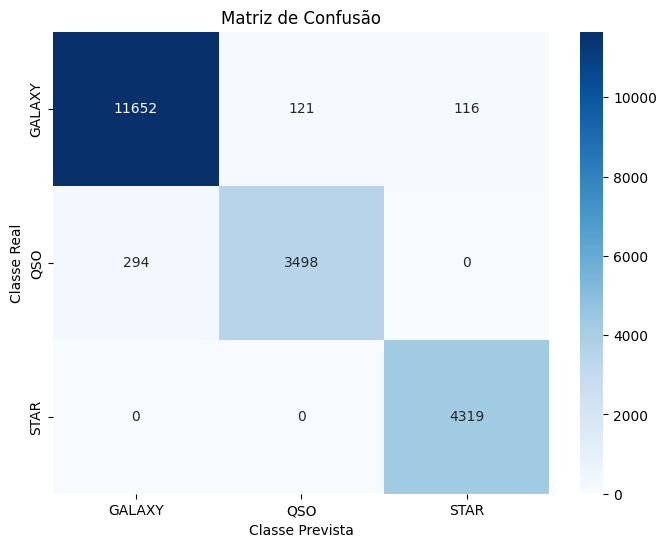

F1-score final: 0.9726


accuracy,▁▁▅▆▆▆▇▇▇▅▇▇▇██▇██████▇▇█▇██▆▇▇█▇████▇██
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
f1_score,▁▁▅▅▆▆▆▇▇▇▇▇▇██▇██████▇▇▇█▆██▇█▇█▇▇█▇███
train_loss,█▆▅▄▃▃▃▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▃▁▂▂▁▁▂▁▂▂▁▂▁
accuracy,0.97285
epoch,54
f1_score,0.97261
train_loss,0.10353
val_loss,0.09112


In [15]:
def train_mlp():
    # Inicializar Run do W&B
    run = wandb.init(project="star-classification", job_type="train", name="mlp_training")
    
    # Configurações do modelo e treino
    config = wandb.config
    config.dropout = 0.3
    config.lr = 0.001
    config.batch_size = 64
    config.epochs = 100
    config.patience = 10 # Early Stopping

    # Carregar dados
    train_loader, test_loader, num_classes, class_names = prepare_stellar_dataloaders(
        'data/train_selected.csv', 'data/test_selected.csv', config.batch_size
    )
    
    input_dim = next(iter(train_loader))[0].shape[1]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = StellarMLP(input_dim, num_classes, config.dropout).to(device)
    criterion = nn.NLLLoss()
    optimizer = optim.Adam(model.parameters(), lr=config.lr)
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    wandb.watch(model, criterion, log="all", log_freq=10)

    for epoch in range(config.epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validação
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        # Listas para armazenar y_true e y_pred para a matriz de confusão
        all_y_true = []
        all_y_pred = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
                
                # Coletando dados para a matriz (apenas na última época ou para análise)
                all_y_true.extend(y_batch.cpu().numpy())
                all_y_pred.extend(predicted.cpu().numpy())

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(test_loader)
        accuracy = correct / total
        
        f1 = f1_score(all_y_true, all_y_pred, average='weighted')

        wandb.log({
            "epoch": epoch, 
            "train_loss": avg_train_loss, 
            "val_loss": avg_val_loss, 
            "accuracy": accuracy,
            "f1_score": f1
        })

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), "best_stellar_mlp.pt")
            
            # Armazenar os melhores y_true e y_pred para a matriz final
            best_y_true = all_y_true
            best_y_pred = all_y_pred
            
            artifact = wandb.Artifact("stellar_mlp_model", type="model")
            artifact.add_file("best_stellar_mlp.pt")
            wandb.log_artifact(artifact)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= config.patience:
                print(f"Early stopping na época {epoch}")
                break

    print("Treinamento concluído.")

    cm = confusion_matrix(best_y_true, best_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Matriz de Confusão')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.show()

    print(f"F1-score final: {f1:.4f}")

    wandb.finish()

train_mlp()
